<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/logistic_%20regression_Machine_Failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/machine_failure.xlsx')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display the shape of the DataFrame
print(f'Shape of the dataset: {df.shape}')

First 5 rows of the dataset:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Shape of the dataset: (10000, 14)


In [3]:
# 1. Check for missing values
print('Missing values before cleaning:')
display(df.isnull().sum())

# 2. Check for duplicate rows and remove them
initial_rows = df.shape[0]
duplicate_rows = df.duplicated().sum()
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f'\nRemoved {duplicate_rows} duplicate rows. DataFrame now has {df.shape[0]} rows.')
else:
    print('\nNo duplicate rows found.')

# 3. Drop columns not useful for prediction
columns_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# 4. Print the cleaned DataFrame's shape and column names
print(f'\nShape of the cleaned DataFrame: {df.shape}')
print('Column names of the cleaned DataFrame:')
print(df.columns.tolist())

Missing values before cleaning:


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0



No duplicate rows found.

Shape of the cleaned DataFrame: (10000, 7)
Column names of the cleaned DataFrame:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


In [4]:
# 1. Define Y (target variable) as the 'Machine failure' column
Y = df['Machine failure']

# 2. Define X (features)
X = df[['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]

# 3. One-hot encode the 'Type' column
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

# 4. Print the final shape of X and Y, and show the first 3 rows of X
print(f'Shape of X (features): {X.shape}')
print(f'Shape of Y (target): {Y.shape}')
print('\nFirst 3 rows of X:')
display(X.head(3))

Shape of X (features): (10000, 7)
Shape of Y (target): (10000,)

First 3 rows of X:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False


Count of Machine failure:


,count
Machine failure,
0,9661
1,339


/tmp/ipykernel_10689/1293876465.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')


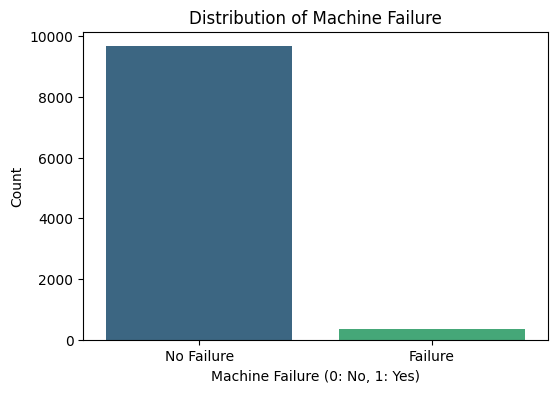

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Show the count of Machine failure vs no failure and a bar chart
print('Count of Machine failure:')
failure_counts = df['Machine failure'].value_counts()
display(failure_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')
plt.title('Distribution of Machine Failure')
plt.xlabel('Machine Failure (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Failure', 'Failure'])
plt.show()

### Note on Dataset Imbalance

As observed from the `Machine failure` distribution, the dataset is highly imbalanced. Only a small percentage of machines (approximately 3.4%) experienced failure. This is an important consideration for model training, as it can lead to models that perform well on the majority class (no failure) but poorly on the minority class (failure).

In [6]:
# 2. Show summary statistics (mean, min, max) for all numeric columns
print('\nSummary statistics for numeric columns:')
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
display(df[numeric_cols].agg(['mean', 'min', 'max']))


Summary statistics for numeric columns:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
mean,300.00493,310.00556,1538.7761,39.98691,107.951,0.0339
min,295.30000,305.70000,1168.0000,3.80000,0.000,0.0000
max,304.50000,313.80000,2886.0000,76.60000,253.000,1.0000


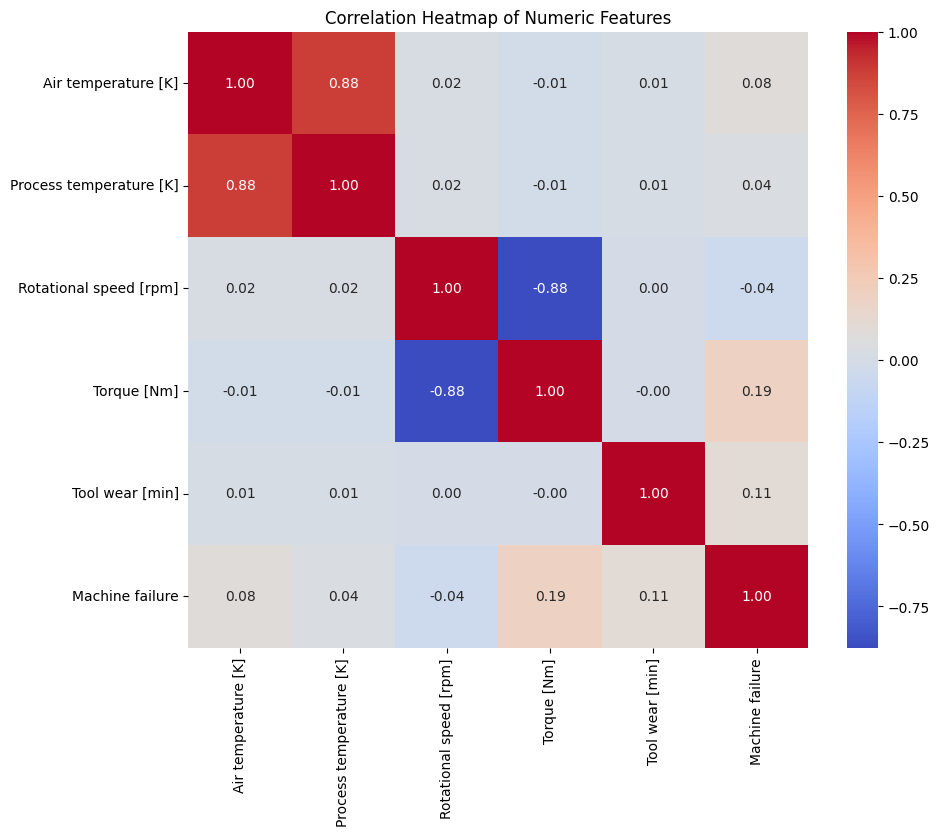

In [7]:
# 3. Plot a correlation heatmap of all numeric features with the target 'Machine failure'
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

/tmp/ipykernel_10689/4219066945.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_10689/4219066945.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df, ax=axes[1], palette='pastel')


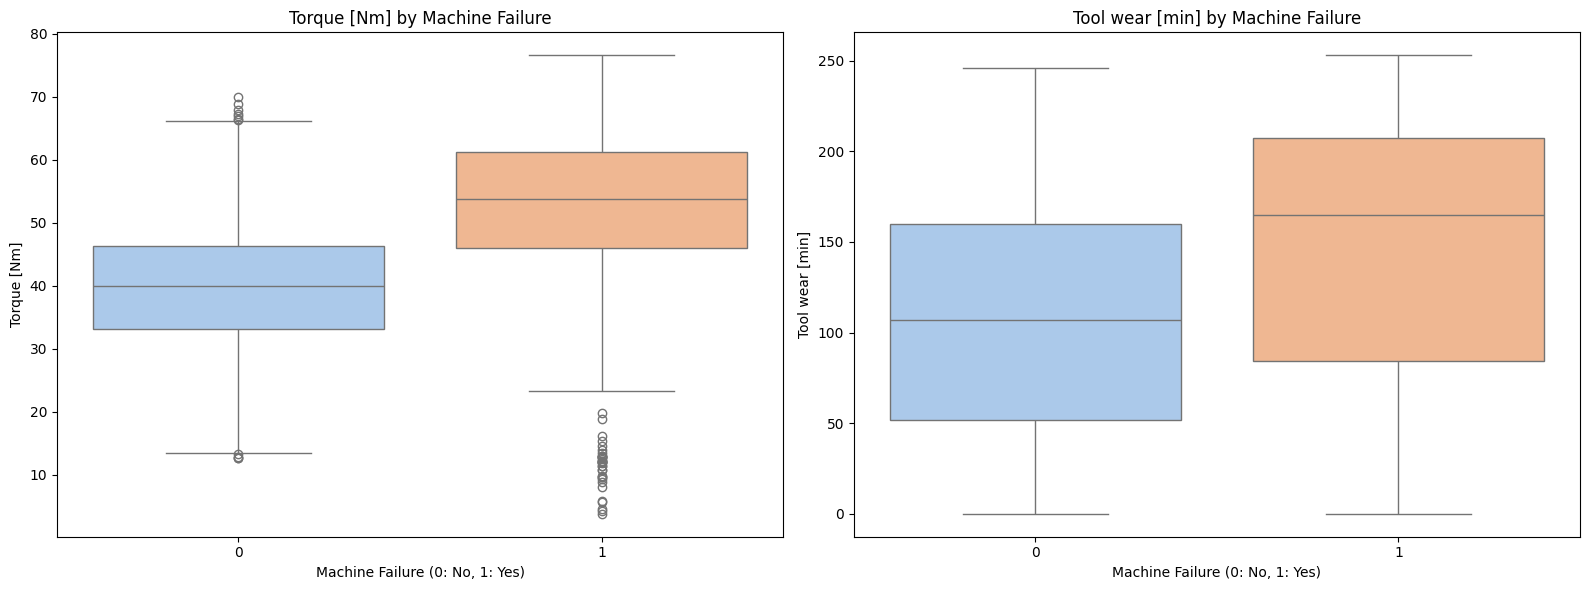

In [8]:
# 4. Plot boxplots comparing 'Torque [Nm]' and 'Tool wear [min]' between failed and non-failed machines

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Torque [Nm] by Machine Failure')
axes[0].set_xlabel('Machine Failure (0: No, 1: Yes)')
axes[0].set_ylabel('Torque [Nm]')

sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Tool wear [min] by Machine Failure')
axes[1].set_xlabel('Machine Failure (0: No, 1: Yes)')
axes[1].set_ylabel('Tool wear [min]')

plt.tight_layout()
plt.show()

/tmp/ipykernel_10689/2727105322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df, palette='muted')


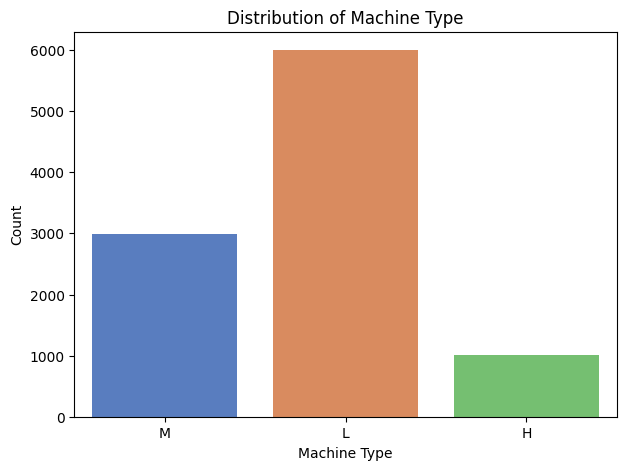

In [9]:
# 5. Show the distribution of the 'Type' column with a count plot
plt.figure(figsize=(7, 5))
sns.countplot(x='Type', data=df, palette='muted')
plt.title('Distribution of Machine Type')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Split the data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of Y_train: {Y_train.shape}')
print(f'Shape of Y_test: {Y_test.shape}')

# 2. Scale the numeric features using StandardScaler
scaler = StandardScaler()

# Identify numeric columns for scaling (all except 'Type' dummy variables)
numeric_cols = X_train.columns.drop(['Type_L', 'Type_M'], errors='ignore')

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('\nFirst 3 rows of scaled X_train:')
display(X_train_scaled.head(3))

# 3. Build a Logistic Regression model with class_weight='balanced'
model = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear') # 'liblinear' is a good choice for small datasets and 'l1' regularization

# 4. Train the model on the training data
model.fit(X_train_scaled, Y_train)

# 5. Print a confirmation message
print('\nLogistic Regression model trained successfully with class_weight="balanced".')

Shape of X_train: (8000, 7)
Shape of X_test: (2000, 7)
Shape of Y_train: (8000,)
Shape of Y_test: (2000,)

First 3 rows of scaled X_train:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
4058,0.998914,0.604282,-0.460607,0.718305,-0.843997,False,True
1221,-1.505194,-1.153260,-0.775574,0.638456,0.382263,False,True
6895,0.498092,1.077466,-1.007654,0.558607,0.460870,False,True



Logistic Regression model trained successfully with class_weight="balanced".


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import statsmodels.api as sm

# Re-define X and Y from previous steps if kernel state was lost
# Assuming X and Y are already defined globally from cell 0639fca1

# 1. Split the data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# 2. Scale the numeric features using StandardScaler
scaler = StandardScaler()
numeric_cols = X_train.columns.drop(['Type_L', 'Type_M'], errors='ignore')
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 3. Build and train a Logistic Regression model with class_weight='balanced'
model = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
model.fit(X_train_scaled, Y_train)

# 1. Extract and print the model equation

# Get feature names from X_train_scaled
feature_names = X_train_scaled.columns.tolist()

# Get coefficients and intercept from the sklearn model
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Create a DataFrame for readability
model_equation_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient (beta)': coefficients
})

print('Model Equation (Coefficients):')
display(model_equation_df)
print(f'Intercept (beta0): {intercept:.4f}')

Model Equation (Coefficients):


,Feature,Coefficient (beta)
0,Air temperature [K],1.779217
1,Process temperature [K],-1.229521
2,Rotational speed [rpm],1.729677
3,Torque [Nm],2.403676
4,Tool wear [min],0.859987
5,Type_L,0.442187
6,Type_M,-0.021064


Intercept (beta0): -1.7337


### Explanation of the Logistic Regression Equation

The equation `P(Y=1) = exp(z) / (1 + exp(z))` is the core of Logistic Regression.

Here's what each part means:
*   **`P(Y=1)`**: This represents the probability that the target variable `Y` (in your case, 'Machine failure') is equal to 1 (i.e., a machine failure occurs).
*   **`exp(z)`**: This is the exponential function (e to the power of z).
*   **`z`**: This is the linear combination of your input features and their corresponding coefficients, plus the intercept. It's calculated as `z = beta0 + beta1*x1 + beta2*x2 + ... + betan*xn`.
    *   `beta0` is the intercept.
    *   `beta1, beta2, ... betan` are the coefficients for each feature `x1, x2, ... xn`.

In essence, the linear combination `z` is transformed by the sigmoid (or logistic) function `exp(z) / (1 + exp(z))` to produce a probability value between 0 and 1. This probability can then be used to classify an observation (e.g., if P(Y=1) > 0.5, predict failure; otherwise, predict no failure).

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import statsmodels.api as sm

# Re-define X and Y from previous steps if kernel state was lost
# Assuming X and Y are already defined globally from cell 0639fca1

# 1. Split the data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# 2. Scale the numeric features using StandardScaler
scaler = StandardScaler()
numeric_cols = X_train.columns.drop(['Type_L', 'Type_M'], errors='ignore')
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 3. Build and train a Logistic Regression model with class_weight='balanced'
model = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
model.fit(X_train_scaled, Y_train)

# 3. Perform the Wald test using statsmodels.api.Logit

# Ensure all columns in X_train_scaled are numeric (float) before adding constant
X_train_scaled = X_train_scaled.astype(float)

# Add a constant (intercept) to the training data for statsmodels
X_train_sm = sm.add_constant(X_train_scaled, has_constant='add')

# Create and fit the statsmodels Logistic Regression model
sm_model = sm.Logit(Y_train, X_train_sm)
result = sm_model.fit()

print('\nWald Test Results (Statsmodels Summary):')
# Display the summary which includes z-scores and p-values
print(result.summary())

# 4. Print which features have p-value < 0.05 (significant) and which do not

p_values = result.pvalues
significant_features = p_values[p_values < 0.05].index.tolist()
non_significant_features = p_values[p_values >= 0.05].index.tolist()

print('\nFeatures with p-value < 0.05 (Statistically Significant):')
if 'const' in significant_features:
    significant_features.remove('const') # 'const' is the intercept, usually not listed as a 'feature'
print(significant_features if significant_features else 'No features are statistically significant at p < 0.05 (excluding intercept).')

print('\nFeatures with p-value >= 0.05 (Not Statistically Significant):')
if 'const' in non_significant_features:
    non_significant_features.remove('const')
print(non_significant_features if non_significant_features else 'All features are statistically significant at p < 0.05 (excluding intercept).')

Optimization terminated successfully.
         Current function value: 0.095347
         Iterations 9

Wald Test Results (Statsmodels Summary):
                           Logit Regression Results                           
Dep. Variable:        Machine failure   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7992
Method:                           MLE   Df Model:                            7
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.3556
Time:                        05:17:49   Log-Likelihood:                -762.78
converged:                       True   LL-Null:                       -1183.7
Covariance Type:            nonrobust   LLR p-value:                1.707e-177
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -5.3924      

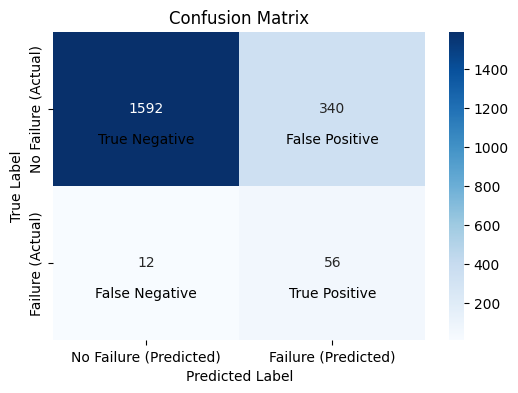


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [13]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Predict on the test set
Y_pred = model.predict(X_test_scaled)

# Generate Confusion Matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)

# Display Confusion Matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure (Predicted)', 'Failure (Predicted)'],
            yticklabels=['No Failure (Actual)', 'Failure (Actual)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Add custom labels
labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
for i, text in enumerate(conf_matrix.flatten()):
    plt.text(i % 2 + 0.5, i // 2 + 0.7, labels[i], ha='center', va='center', color='black', fontsize=10)

plt.show()

# 2. Print the Classification Report
print('\nClassification Report:')
print(classification_report(Y_test, Y_pred))

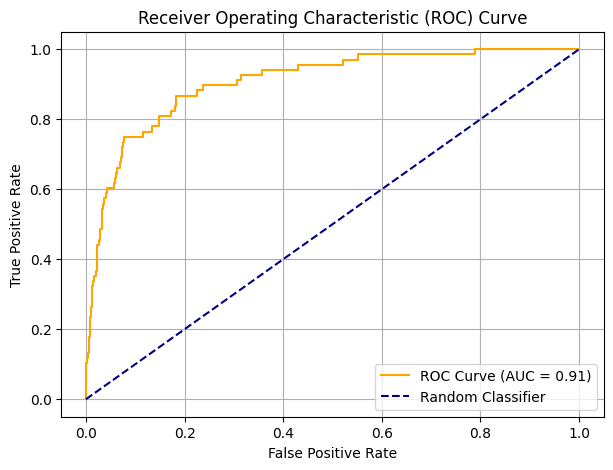

AUC Score: 0.91


In [14]:
# 3. Plot the ROC Curve and calculate the AUC score
Y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class (failure)
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)
auc_score = roc_auc_score(Y_test, Y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f'AUC Score: {auc_score:.2f}')

### Evaluation Notes:

**4. Log-Likelihood Ratio (LLR) Test:**

From the `statsmodels` summary of the Wald test previously generated (cell `70d8de52`), we can observe the `LLR p-value`. If this value is very small (typically < 0.05), it suggests that our model with predictors is significantly better than a null model (a model with only an intercept) in explaining the variance in the target variable. In your previous output, the `LLR p-value` was `1.707e-177`, which is extremely small, indicating that **the overall model is statistically significant**.

**5. Focus on Recall for Class 1:**

Given the highly imbalanced nature of the dataset (only ~3.4% machine failures), it's crucial to pay close attention to **Recall for class 1 (Machine Failure)**. High recall for class 1 means that our model is effective at identifying a large proportion of the actual machine failures. While accuracy can be misleading in imbalanced datasets, recall ensures we are not missing too many critical events. The **F1-score** for class 1 also provides a good balance between precision and recall for the minority class.